In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import nnls, minimize

df = pd.read_csv("data.csv", index_col=0)
df

,PSC,JUNTS,ERC,PP,VOX,COMUNS,CUP,ALIANÇA.CAT,Altres,Cs,Abstenció
1980,0.138185,0.171275,0.054873,0.014556,0.000000,0.115557,0.000000,0.000000,0.117144,0.000000,0.388410
1984,0.193811,0.301318,0.028411,0.049647,0.000000,0.035962,0.000000,0.000000,0.031802,0.000000,0.359048
1988,0.177197,0.272179,0.024616,0.031648,0.000000,0.046166,0.000000,0.000000,0.039541,0.000000,0.408652
1992,0.152089,0.255296,0.043962,0.032968,0.000000,0.035913,0.000000,0.000000,0.025621,0.000000,0.454152
1995,0.159822,0.263467,0.061096,0.084246,0.000000,0.062607,0.000000,0.000000,0.005756,0.000000,0.363006
1999,0.227821,0.226843,0.052261,0.057211,0.000000,0.015129,0.000000,0.000000,0.016845,0.000000,0.403890
2003,0.198586,0.196993,0.104874,0.075627,0.000000,0.046480,0.000000,0.000000,0.008517,0.000000,0.368922
2006,0.153722,0.180767,0.080571,0.060980,0.000000,0.054760,0.000000,0.000000,0.013357,0.017425,0.438418
2010,0.111491,0.234199,0.042640,0.075148,0.000000,0.044927,0.000000,0.000000,0.061473,0.020696,0.409426
2012,0.101217,0.215104,0.095984,0.091014,0.000000,0.069380,0.024398,0.000000,0.040548,0.053099,0.309256


In [2]:
df["PP+VOX"] = df["PP"] + df["VOX"]
df["JUNTS+ALIANÇA"] = df["JUNTS"] + df["ALIANÇA.CAT"]
df.drop(columns=["PP", "VOX", "JUNTS", "ALIANÇA.CAT"], inplace=True)
df

,PSC,ERC,COMUNS,CUP,Altres,Cs,Abstenció,PP+VOX,JUNTS+ALIANÇA
1980,0.138185,0.054873,0.115557,0.000000,0.117144,0.000000,0.388410,0.014556,0.171275
1984,0.193811,0.028411,0.035962,0.000000,0.031802,0.000000,0.359048,0.049647,0.301318
1988,0.177197,0.024616,0.046166,0.000000,0.039541,0.000000,0.408652,0.031648,0.272179
1992,0.152089,0.043962,0.035913,0.000000,0.025621,0.000000,0.454152,0.032968,0.255296
1995,0.159822,0.061096,0.062607,0.000000,0.005756,0.000000,0.363006,0.084246,0.263467
1999,0.227821,0.052261,0.015129,0.000000,0.016845,0.000000,0.403890,0.057211,0.226843
2003,0.198586,0.104874,0.046480,0.000000,0.008517,0.000000,0.368922,0.075627,0.196993
2006,0.153722,0.080571,0.054760,0.000000,0.013357,0.017425,0.438418,0.060980,0.180767
2010,0.111491,0.042640,0.044927,0.000000,0.061473,0.020696,0.409426,0.075148,0.234199
2012,0.101217,0.095984,0.069380,0.024398,0.040548,0.053099,0.309256,0.091014,0.215104


In [3]:
list(df.columns)

['PSC',
 'ERC',
 'COMUNS',
 'CUP',
 'Altres',
 'Cs',
 'Abstenció',
 'PP+VOX',
 'JUNTS+ALIANÇA']

Model ajustat correctament amb pesos temporals (Decay Rate: 0.3)
Pesos aplicats per pas (de més antic a més recent): [0.09 0.13 0.17 0.23 0.31 0.42 0.57 0.77 1.04 1.4  1.89 2.55 3.44]
Model de Cadena de Markov Estable (14 Anys, 9 Partits)
Matriu de Transició Global (Files = Destí, Columnes = Origen):
                  PSC     ERC  COMUNS     CUP  Altres      Cs  Abstenció  PP+VOX  JUNTS+ALIANÇA
PSC            0.7040  0.0377  0.0089  0.0305  0.0003  0.0433     0.0947  0.0046         0.0106
ERC            0.0000  0.4107  0.0525  0.0514  0.0516  0.0309     0.0000  0.0610         0.2203
COMUNS         0.0000  0.0000  0.7851  0.0000  0.0025  0.0000     0.0000  0.0091         0.0322
CUP            0.0000  0.0000  0.0005  0.7965  0.0001  0.0000     0.0000  0.0000         0.0290
Altres         0.0000  0.0004  0.0004  0.0000  0.8253  0.0000     0.0000  0.0000         0.0005
Cs             0.0000  0.0000  0.1207  0.1217  0.0963  0.1781     0.0000  0.1331         0.1379
Abstenció      0.2956  0.5

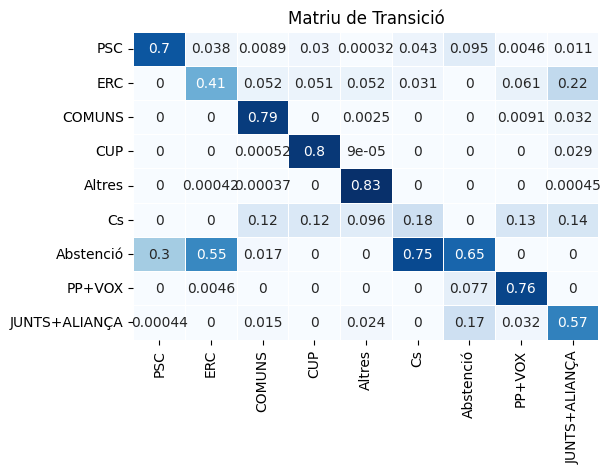

In [4]:
from utils import StableMarkovChain

mc = StableMarkovChain(df)
mc.fit(decay_rate=0.3,sparse_threshold=1e-9,fidelitat_threshold=0.001)

print(mc)
mc.plot_transition_matrix()

PSC              0.149673
ERC              0.080819
COMUNS           0.029497
CUP              0.023168
Altres           0.000677
Cs               0.054896
Abstenció        0.376529
PP+VOX           0.122824
JUNTS+ALIANÇA    0.161917
dtype: float64


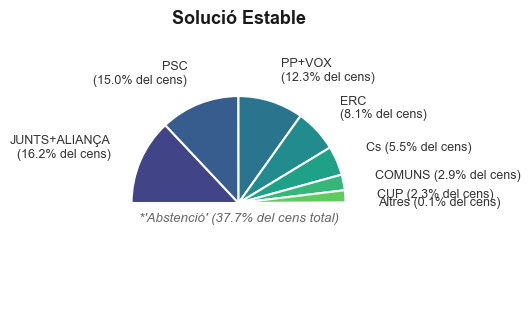

In [5]:
print(mc.get_steady_state())
mc.plot_steady_state()

In [6]:
"""import numpy as np

eigenvalues, eigenvectors = np.linalg.eig(df_P_final)

# Trobar l'índex de l'autovalor més proper a 1
idx = np.argmin(np.abs(eigenvalues - 1))

# Extreure el vector i normalitzar (suma = 1)
pi = np.real(eigenvectors[:, idx])
pi = pi / pi.sum()

partits = list(df_P_final.columns)
for p, v in zip(partits, pi):
    print(f"{p:10s}: {v:.4f}")

###### COMPROVACIÓ DE LA DISTRIBUCIÓ ESTACIONÀRIA ######
print("\nComprovació de la distribució estacionària:")
print(np.allclose(df_P_final @ pi, pi))  # Ha de donar True
print(pi.sum())                    # Ha de donar 1.0"""

'import numpy as np\n\neigenvalues, eigenvectors = np.linalg.eig(df_P_final)\n\n# Trobar l\'índex de l\'autovalor més proper a 1\nidx = np.argmin(np.abs(eigenvalues - 1))\n\n# Extreure el vector i normalitzar (suma = 1)\npi = np.real(eigenvectors[:, idx])\npi = pi / pi.sum()\n\npartits = list(df_P_final.columns)\nfor p, v in zip(partits, pi):\n    print(f"{p:10s}: {v:.4f}")\n\n###### COMPROVACIÓ DE LA DISTRIBUCIÓ ESTACIONÀRIA ######\nprint("\nComprovació de la distribució estacionària:")\nprint(np.allclose(df_P_final @ pi, pi))  # Ha de donar True\nprint(pi.sum())                    # Ha de donar 1.0'

Per al Teorema de Perron-Frobenius, una cadena de Markov irreductible i aperiòdica sempre té una única distribució estacionària π > 0.

In [7]:
mc.verify_steady_state()

VERIFICACIÓ DE L'EXISTÈNCIA DE LA DISTR. ESTACIONÀRIA

1. Matriu estocàstica (columnes sumen 1):
   · Sumes de cada columna: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
   · Columnes sumen 1:      True
   · Valors no negatius:    True

2. Irreductibilitat (tots els estats es comuniquen): True

3. Aperiodicitat (self-loops a la diagonal): True
   → La cadena és APERIÒDICA

EXISTEIX distribució estacionària ÚNICA


True

c:\Users\laiaq\Desktop\MatCAD\S6\ModSim\Oligopolistic-Parties\utils.py:389: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle(


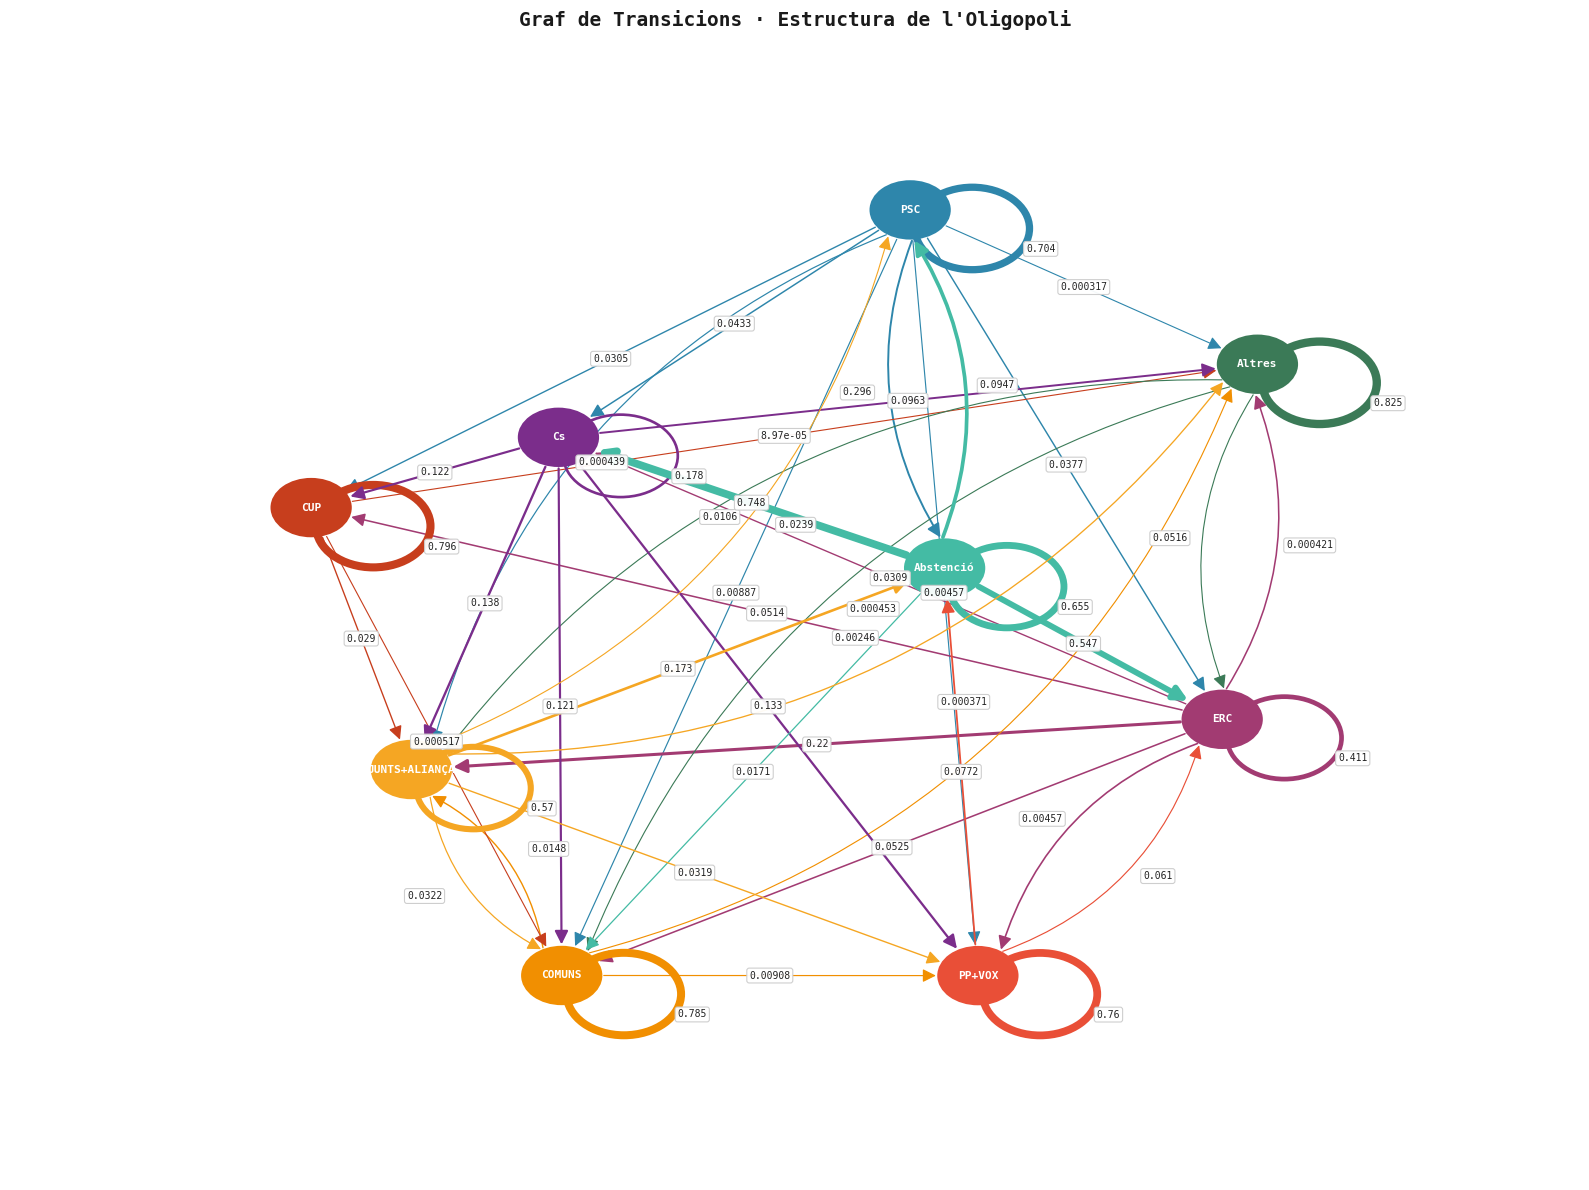

In [8]:
mc.plot_graph()

### Efecte d'una campanya
Per fer-ho canviem un valor de la matriu de transició, augmentant el nombre de votants que es queden del partit politic que fa la campanya.

In [9]:
col = "PSC"
mc.transition_matrix.loc[col, col] = 0.6

# Renormalitzem la fila
mc.transition_matrix[col] /= mc.transition_matrix[col].sum()

# Verifiquem que segueix sumant 1
print(mc.transition_matrix[col].sum())

1.0


PSC              0.136232
ERC              0.082097
COMUNS           0.029964
CUP              0.023534
Altres           0.000688
Cs               0.055763
Abstenció        0.382481
PP+VOX           0.124765
JUNTS+ALIANÇA    0.164476
dtype: float64


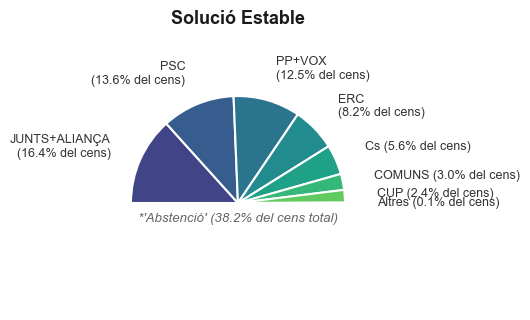

In [10]:
print(mc.get_steady_state())
mc.plot_steady_state()

### Temps per arribar a solució estacionària

Fem una simulació de l'evolució de la matriu de transició a partir de l'estat incial (any 1980). Amb aquesta simulació veiem en quantes eleccions arriba a la solució estàcionaria que haviem calculat anteriorment i fem una aproximació per calcular els anys total (num_eleccions * 4)

In [11]:
pi = mc.get_steady_state().values
p0 = mc.df.iloc[0].values 
p=p0.copy()
epsilon = 1e-5
t = 0
historia = [p0.copy()]

P = mc.transition_matrix.values

# Afegeix un màxim de passos per seguretat
MAX_PASSOS = 10000

while t < MAX_PASSOS:
    p_nou = P @ p
    diferencia = np.max(np.abs(p_nou - pi))
    historia.append(p_nou.copy())
    t += 1
    if diferencia < epsilon:
        break
    p = p_nou

if t == MAX_PASSOS:
    print("No ha convergit en el màxim de passos!")

print(f"Convergència assolida en {t} eleccions (~{t*4} anys)")
print(f"Distribució estacionària π:")
for partit, prob in zip(list(mc.df.columns), pi):
    print(f"  {partit}: {prob:.3f}")

Convergència assolida en 49 eleccions (~196 anys)
Distribució estacionària π:
  PSC: 0.136
  ERC: 0.082
  COMUNS: 0.030
  CUP: 0.024
  Altres: 0.001
  Cs: 0.056
  Abstenció: 0.382
  PP+VOX: 0.125
  JUNTS+ALIANÇA: 0.164


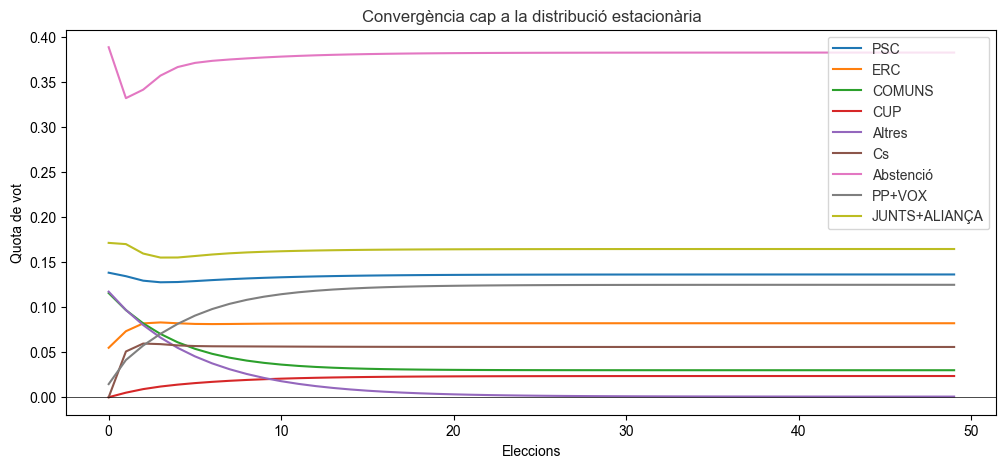

In [12]:
import matplotlib.pyplot as plt

historia = np.array(historia)

plt.figure(figsize=(12, 5))
for j, partit in enumerate(list(df.columns)):
    plt.plot(historia[:, j], label=partit)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.xlabel("Eleccions")
plt.ylabel("Quota de vot")
plt.title("Convergència cap a la distribució estacionària")
plt.legend()
plt.show()

### Costumer lifetime value

Busquem el número d'eleccions consecutives que de mitjana un votant votaria al mateix partit: $\frac{1}{1-retenció}$

In [13]:
retencio = mc.transition_matrix.values.diagonal()
print("Retenció (probabilitat de mantenir votants):")

clv = 1 / (1 - retencio)

print("CLV (Customer Lifetime Value) estimat per cada partit:")
for partit, clv_value in zip(list(df.columns), clv):
    print(f"  {partit}: {round(clv_value, 2)} ~ {round(clv_value, 0)} eleccions")

Retenció (probabilitat de mantenir votants):
CLV (Customer Lifetime Value) estimat per cada partit:
  PSC: 3.03 ~ 3.0 eleccions
  ERC: 1.7 ~ 2.0 eleccions
  COMUNS: 4.65 ~ 5.0 eleccions
  CUP: 4.91 ~ 5.0 eleccions
  Altres: 5.72 ~ 6.0 eleccions
  Cs: 1.22 ~ 1.0 eleccions
  Abstenció: 2.9 ~ 3.0 eleccions
  PP+VOX: 4.17 ~ 4.0 eleccions
  JUNTS+ALIANÇA: 2.32 ~ 2.0 eleccions
